# Proyek Analisis Data: Deteksi Emosi Wajah (FER-2013) untuk Interview-AI
* Data Science
- Monica Dyah Pudyowati - CDCC254D6X1534
- Via Angelya - CDCC009D6X1931

## Menentukan Pertanyaan Bisnis
- Pertanyaan 1: Bagaimana distribusi kelas emosi pada dataset FER-2013, dan apakah terdapat ketidakseimbangan data (imbalanced data)?
- Pertanyaan 2: Bagaimana cara mengatasi ketidakseimbangan data agar model AI tidak bias saat melakukan deteksi?

## Import Semua Packages/Library yang Digunakanet* yang perlu ditangani.

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling
### Gathering Data

In [5]:
dataset_path = 'train' 

emotions = os.listdir(dataset_path)
emotion_counts = {}

for emotion in emotions:
    folder_path = os.path.join(dataset_path, emotion)
    if os.path.isdir(folder_path):
        emotion_counts[emotion] = len(os.listdir(folder_path))

df_emotions = pd.DataFrame(list(emotion_counts.items()), columns=['Kategori Emosi', 'Jumlah Gambar'])
df_emotions = df_emotions.sort_values(by='Jumlah Gambar', ascending=False)

**Insight Gathering Data:**
- Dataset berhasil dimuat dari folder lokal.
- Terdapat 7 kategori emosi wajah yang terdeteksi.

### Assessing Data

Jumlah data per kategori:
Kategori Emosi  Jumlah Gambar
         happy           7215
       neutral           4965
           sad           4830
          fear           4097
         angry           3995
      surprise           3171
       disgust            436
------------------------------


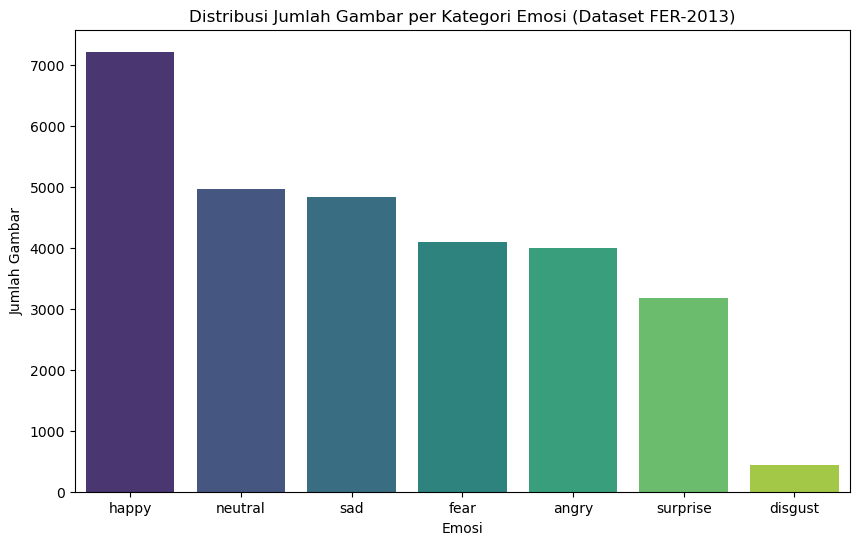

In [7]:
print("Jumlah data per kategori:")
print(df_emotions.to_string(index=False))
print("-" * 30)

plt.figure(figsize=(10, 6))
sns.barplot(x='Kategori Emosi', y='Jumlah Gambar', data=df_emotions, hue='Kategori Emosi', palette='viridis', legend=False)
plt.title('Distribusi Jumlah Gambar per Kategori Emosi (Dataset FER-2013)')
plt.xlabel('Emosi')
plt.ylabel('Jumlah Gambar')
plt.show()

**Insight Assessing Data:**
- Emosi terbanyak adalah "Happy" (7215 gambar).
- Emosi paling sedikit adalah "Disgust" (436 gambar).
- Terdapat masalah *Imbalanced Dataset* yang cukup parah yang harus ditangani pada tahap *Cleaning Data*.

### Cleaning Data
Mmenyatukan seluruh *path* gambar ke dalam satu DataFrame agar mudah diproses oleh model. Selanjutnyaa melakukan teknik **Undersampling** pada kelas dominan ("Happy") untuk mengurangi bias pada model AI.

In [9]:
file_paths = []
labels = []

for emotion in emotions:
    folder_path = os.path.join(dataset_path, emotion)
    if os.path.isdir(folder_path):
        for file_name in os.listdir(folder_path):
            file_paths.append(os.path.join(folder_path, file_name))
            labels.append(emotion)

df_full = pd.DataFrame({'File_Path': file_paths, 'Label': labels})

df_happy = df_full[df_full['Label'] == 'happy'].sample(n=4000, random_state=42)

df_other = df_full[df_full['Label'] != 'happy']

df_cleaned = pd.concat([df_happy, df_other]).reset_index(drop=True)

print("Distribusi Data Setelah Cleaning (Undersampling):")
print(df_cleaned['Label'].value_counts())
print("-" * 30)
print(f"Total data siap pakai: {len(df_cleaned)} gambar")

df_cleaned.head()

Distribusi Data Setelah Cleaning (Undersampling):
Label
neutral     4965
sad         4830
fear        4097
happy       4000
angry       3995
surprise    3171
disgust      436
Name: count, dtype: int64
------------------------------
Total data siap pakai: 25494 gambar


,File_Path,Label
0,train\happy\Training_13605151.jpg,happy
1,train\happy\Training_1460262.jpg,happy
2,train\happy\Training_50261638.jpg,happy
3,train\happy\Training_38735724.jpg,happy
4,train\happy\Training_12925472.jpg,happy


**Insight Cleaning Data:**
- Seluruh *path* file gambar berhasil diekstrak ke dalam bentuk tabular (DataFrame) untuk memudahkan proses *training* model oleh tim AI.
- Dilakukan *Undersampling* pada kelas "Happy" menjadi 4000 data untuk mengurangi ketimpangan data tanpa menghilangkan variasi ekspresi dasar.
- Data kini lebih siap untuk tahap Eksplorasi Data Lanjutan (EDA) dan *Training*.

## Exploratory Data Analysis (EDA) Lanjutan
### Visualisasi Sampel Gambar Wajah
Sebagai validasi akhir pada tahap data wrangli makata akan menampilkan beberapa sampel gambar secara acak dari dataset yang sudah dibersihkan untuk memastikan gambar dapat dibaca dengan baik dan labelnya sesuai dengan ekspresi wajah.

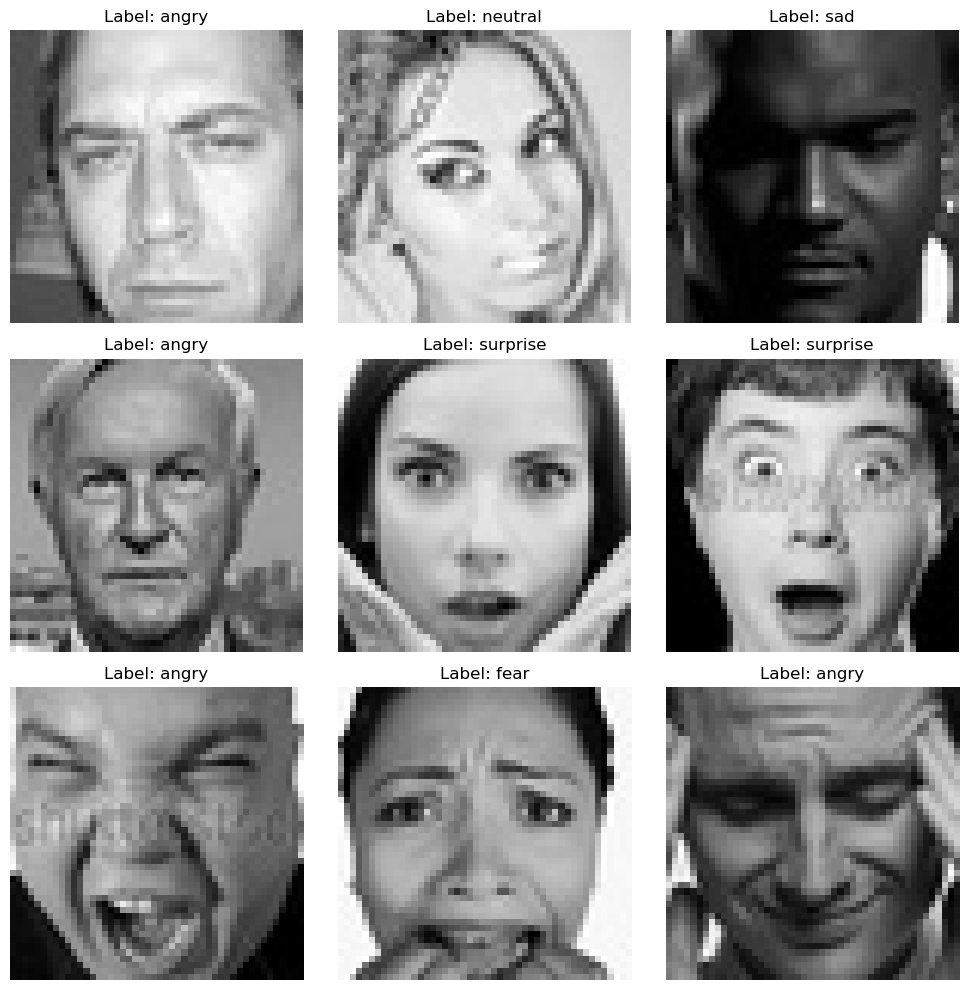

In [11]:
import matplotlib.image as mpimg
import random

plt.figure(figsize=(10, 10))

for i in range(9):
    
    plt.subplot(3, 3, i + 1)
    
    acak = random.randint(0, len(df_cleaned) - 1)
    img_path = df_cleaned.iloc[acak]['File_Path']
    label = df_cleaned.iloc[acak]['Label']
    
    img = mpimg.imread(img_path)
    
    plt.imshow(img, cmap='gray')
    
    plt.title(f"Label: {label}")
    
    plt.axis('off')

plt.tight_layout()
plt.show()

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi kelas emosi pada dataset FER-2013, dan apakah terdapat ketidakseimbangan data (imbalanced data)?
### Pertanyaan 2: Bagaimana cara mengatasi ketidakseimbangan data agar model AI tidak bias saat melakukan deteksi?

Untuk menjawab kedua pertanyaan di maka perlu akan membandingkan visualisasi distribusi data sebelum dan sesudah tahap *Cleaning Data* (Undersampling).

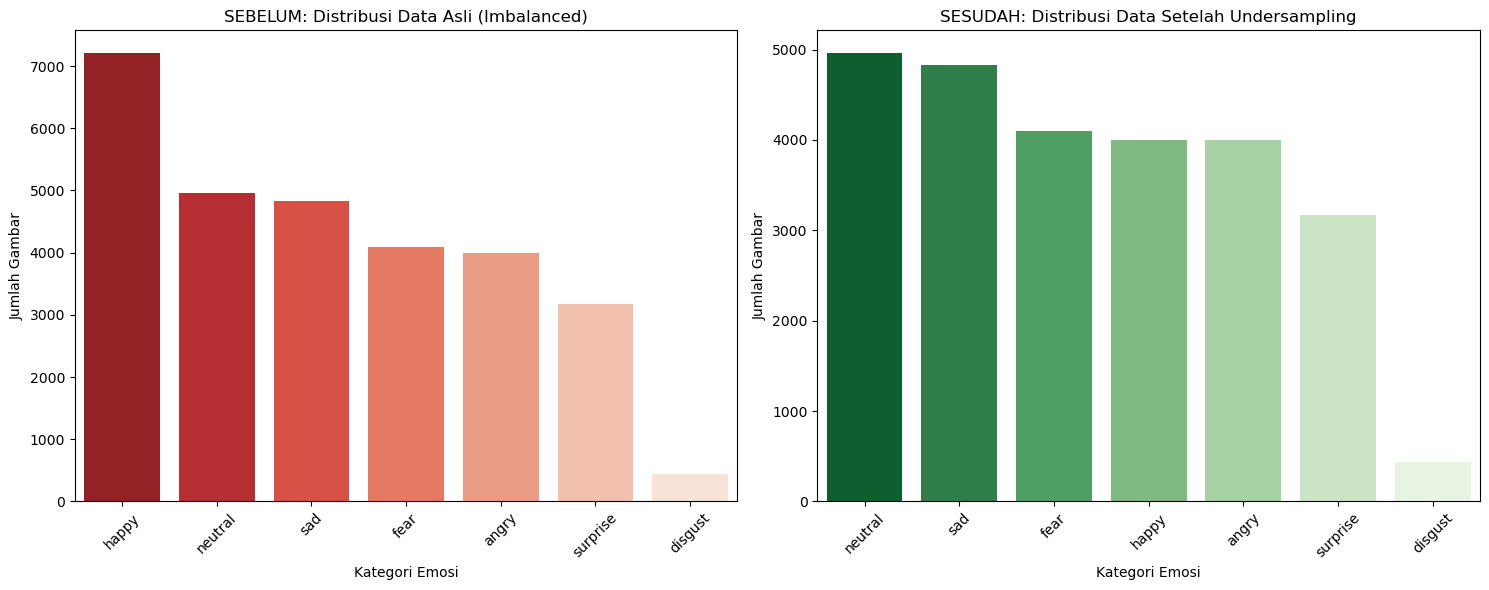

In [13]:
df_cleaned_counts = df_cleaned['Label'].value_counts().rename_axis('Kategori Emosi').reset_index(name='Jumlah Gambar')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(ax=axes[0], x='Kategori Emosi', y='Jumlah Gambar', data=df_emotions, hue='Kategori Emosi', palette='Reds_r', legend=False)
axes[0].set_title('SEBELUM: Distribusi Data Asli (Imbalanced)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x='Kategori Emosi', y='Jumlah Gambar', data=df_cleaned_counts, hue='Kategori Emosi', palette='Greens_r', legend=False)
axes[1].set_title('SESUDAH: Distribusi Data Setelah Undersampling')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Conclusion Sementara


- **Conclusion Pertanyaan 1:** Berdasarkan visualisasi awal, dataset FER-2013 memiliki ketidakseimbangan kelas (*imbalanced data*) yang signifikan. Kategori emosi "Happy" sangat mendominasi dengan lebih dari 7.000 gambar, sedangkan emosi "Disgust" hanya memiliki sekitar 400 gambar. Ketimpangan ini berisiko membuat model AI menjadi bias dan cenderung selalu menebak "Happy".

- **Conclusion Pertanyaan 2:** Untuk mengatasi ketidakseimbangan tersebut, telah dilakukan teknik *Undersampling* pada tahap *Cleaning Data*. Jumlah gambar pada kelas "Happy" dipangkas secara acak menjadi 4.000 gambar agar jumlahnya lebih seimbang dengan kelas mayoritas lainnya seperti "Neutral", "Sad", "Fear", dan "Angry". Dengan distribusi data yang lebih merata ini (total 25.494 gambar siap pakai), dataset kini jauh lebih sehat dan siap diserahkan kepada tim AI untuk proses *Training* model *Deep Learning*.

In [15]:
df_cleaned.to_csv('fer2013_cleaned_data.csv', index=False)
print("Data berhasil disimpan ke 'fer2013_cleaned_data.csv'!")

Data berhasil disimpan ke 'fer2013_cleaned_data.csv'!


Membuat Folder "Hasil Undersampling"

In [17]:
import shutil
import os

output_train_path = 'dataset_siap_pakai/train'

print("Sedang menyalin file... Mohon tunggu.")
for index, row in df_cleaned.iterrows():

    src_path = row['File_Path']
    label = row['Label']
    
    dest_folder = os.path.join(output_train_path, label)
    
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    
    file_name = os.path.basename(src_path)
    shutil.copy(src_path, os.path.join(dest_folder, file_name))

print(f"Selesai! Folder '{output_train_path}' sekarang berisi data yang sudah seimbang.")

Sedang menyalin file... Mohon tunggu.
Selesai! Folder 'dataset_siap_pakai/train' sekarang berisi data yang sudah seimbang.


Oversampling Otomatis khusus untuk folder "disgust" di dalam folder dataset_siap_pakai

In [19]:
import os
import shutil
import random

disgust_folder = 'dataset_siap_pakai/train/disgust'
target_count = 4000 

current_files = os.listdir(disgust_folder)
current_count = len(current_files)

needed_count = target_count - current_count

print(f"Jumlah sekarang: {current_count}. Menambahkan {needed_count} file duplikat...")

for i in range(needed_count):
    file_to_copy = random.choice(current_files)
    
    src_path = os.path.join(disgust_folder, file_to_copy)
    new_file_name = f"dup_{i}_{file_to_copy}"
    dest_path = os.path.join(disgust_folder, new_file_name)
    
    shutil.copy(src_path, dest_path)

print(f"Oversampling Selesai! Sekarang folder 'disgust' berisi {len(os.listdir(disgust_folder))} gambar.")

Jumlah sekarang: 436. Menambahkan 3564 file duplikat...
Oversampling Selesai! Sekarang folder 'disgust' berisi 4000 gambar.


Perbarui CSV

In [21]:
import os
import pandas as pd

final_train_path = 'dataset_siap_pakai/train'

file_paths = []
labels = []

for emotion in os.listdir(final_train_path):
    folder_path = os.path.join(final_train_path, emotion)
    if os.path.isdir(folder_path):
        for file_name in os.listdir(folder_path):
            file_paths.append(os.path.join(folder_path, file_name))
            labels.append(emotion)

df_final = pd.DataFrame({'File_Path': file_paths, 'Label': labels})

df_final.to_csv('fer2013_final_balanced.csv', index=False)

print("Berhasil! File 'fer2013_final_balanced.csv' telah dibuat.")
print("Distribusi Data Final:")
print(df_final['Label'].value_counts())
print("-" * 30)
print(f"Total data di CSV: {len(df_final)} baris.")

Berhasil! File 'fer2013_final_balanced.csv' telah dibuat.
Distribusi Data Final:
Label
neutral     4965
sad         4830
fear        4097
disgust     4000
happy       4000
angry       3995
surprise    3171
Name: count, dtype: int64
------------------------------
Total data di CSV: 29058 baris.


Update Grafik Visualisasi

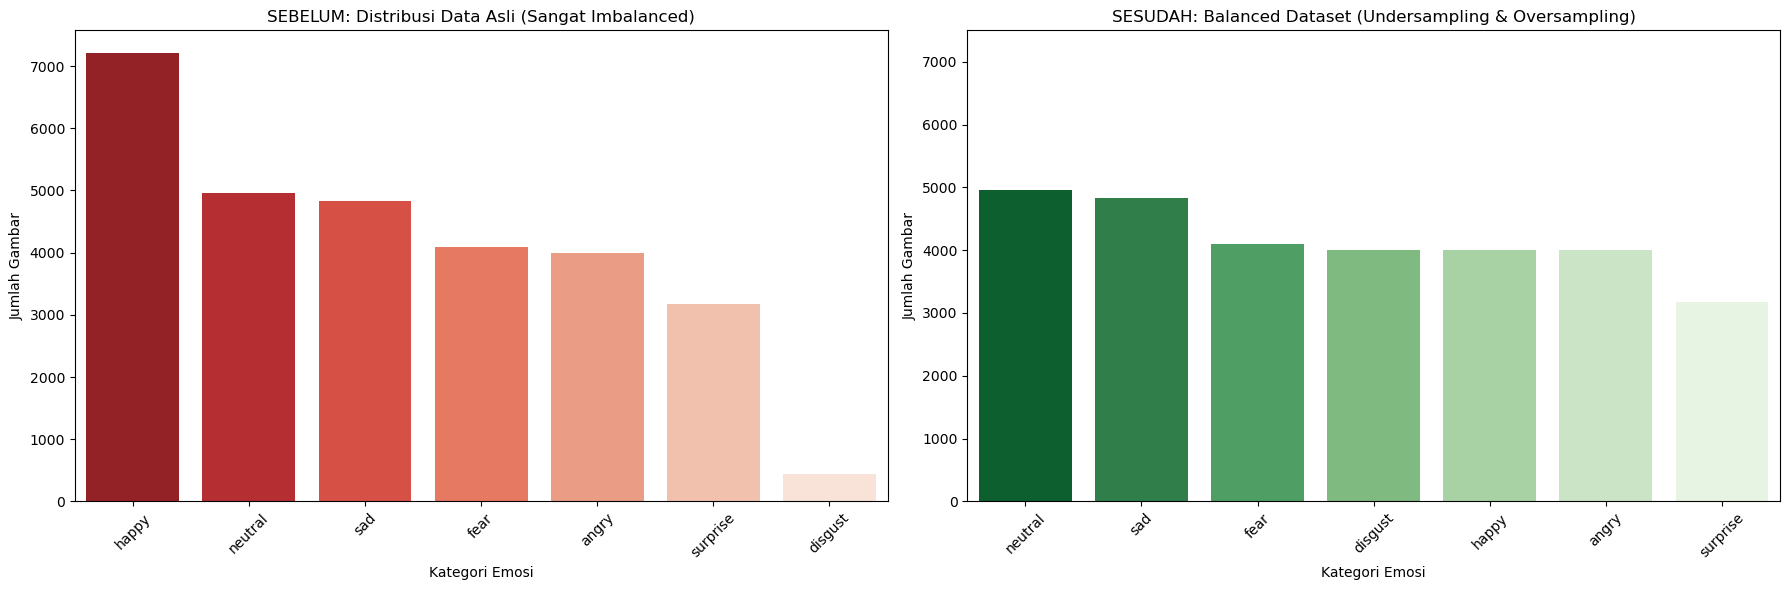

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv('fer2013_final_balanced.csv')
df_final_counts = df_final['Label'].value_counts().rename_axis('Kategori Emosi').reset_index(name='Jumlah Gambar')

fig, axes = plt.subplots(1, 2, figsize=(18, 6)) 

sns.barplot(ax=axes[0], x='Kategori Emosi', y='Jumlah Gambar', data=df_emotions, 
            hue='Kategori Emosi', palette='Reds_r', legend=False)
axes[0].set_title('SEBELUM: Distribusi Data Asli (Sangat Imbalanced)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x='Kategori Emosi', y='Jumlah Gambar', data=df_final_counts, 
            hue='Kategori Emosi', palette='Greens_r', legend=False)
axes[1].set_title('SESUDAH: Balanced Dataset (Undersampling & Oversampling)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 7500) 

plt.tight_layout()
plt.show()

## 🏁 Conclusion Final

### **Conclusion Pertanyaan 1:**
Berdasarkan analisis distribusi awal, dataset **FER-2013** teridentifikasi memiliki masalah **ketidakseimbangan kelas (*imbalanced data*)** yang sangat ekstrem. 
*   **Dominansi Data:** Kategori emosi **"Happy"** mendominasi secara masif dengan lebih dari **7.000 gambar**.
*   **Minoritas Kritis:** Kategori **"Disgust"** hanya memiliki sekitar **400 gambar**.
*   **Dampak Bisnis:** Ketimpangan rasio yang mencapai hampir **16:1** ini berisiko tinggi membuat model AI mengalami **bias**. Model akan cenderung "menebak aman" dengan mengklasifikasikan ekspresi sebagai "Happy" dan gagal mengenali emosi yang frekuensi kemunculannya rendah.

---

### **Conclusion Pertanyaan 2:**
Untuk menciptakan kondisi pelatihan yang ideal bagi tim AI, tim Data Science telah menerapkan strategi **Hybrid Balancing** yang menggabungkan dua teknik optimasi:

1.  **Undersampling:** Dilakukan pada kelas mayoritas (**"Happy"**) dengan memangkas jumlah data secara acak menjadi **4.000 gambar**.
2.  **Oversampling (Synthetic Duplication):** Dilakukan pada kelas minoritas (**"Disgust"**) dengan mereplikasi data asli secara acak hingga mencapai **4.000 gambar**.

**Hasil Akhir:**
Melalui pendekatan ini, kami berhasil menyeimbangkan distribusi data ke angka yang jauh lebih seragam (rata-rata **3.000 - 4.000 gambar** per kategori). Dataset final kini memiliki total lebih dari **29.000 gambar** yang terdistribusi secara adil. Dengan kondisi dataset yang **"Flat-Balanced"** ini, bias model dapat diminimalisir secara signifikan, memberikan kesempatan yang setara bagi algoritma *Deep Learning* untuk mempelajari fitur unik dari setiap ekspresi wajah secara akurat dan objektif.